## Part 1

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import re
from nltk.corpus import stopwords
import nltk
import Stemmer
from tqdm.notebook import tqdm
nltk.download('stopwords', quiet=True)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
# Import small test dataset (for checking that the functions work)
url = "https://raw.githubusercontent.com/several27/FakeNewsCorpus/master/news_sample.csv"
df = pd.read_csv(url)

In [11]:
# Define regex patterns to use for tokenization:

# URLs
URL_RE = re.compile(r'https?://\S+|www\.\S+')

# Dates
DATE_RE = re.compile(r'\b\d{1,4}[-/]\d{1,2}[-/]\d{1,4}\b')

# Numbers
NUM_RE = re.compile(r'\b\d+\b')

# Words + special tokens.
TOKENS = re.compile(r'<[^>]+>|[a-zA-Z]+')

# Get stopword list and stemmer.
stop_words = set(stopwords.words('english'))

stemmer = Stemmer.Stemmer('english')

In [12]:
def preprocessing(df):

    # Initialize vocabularies
    vocab_before  = set()
    vocab_no_stop = set()
    vocab_stemmed = set()
    tokenized = []

    # Go through each row (with progress bar)
    for text in tqdm(df["content"], total=len(df), desc="Preprocessing", mininterval=1.0):

        # Make all text lower case
        text = text.lower()

        # Switch out URLs, dates and numbers with special tokens
        text = URL_RE.sub(" <URL> ", text)
        text = DATE_RE.sub(" <DATE> ", text)
        text = NUM_RE.sub(" <NUM> ", text)

        # Make a list of tokens in the text
        tokens_before  = TOKENS.findall(text)

        # Remove stop words
        tokens_no_stop = [t for t in tokens_before if t not in stop_words]

        # Stem the tokens
        tokens_stemmed = stemmer.stemWords(tokens_no_stop)

        # Save the vocabularies at each step
        vocab_before.update(tokens_before)
        vocab_no_stop.update(tokens_no_stop)
        vocab_stemmed.update(tokens_stemmed)
        tokenized.append(tokens_stemmed)

    # Save results in the dataframe
    df["tokenized"] = tokenized

    # Remove unnecessary data from memory
    df.drop(columns=['content'], inplace=True)

    # Print out relevant measures
    for t, vocab in (('After removing stopwords', vocab_no_stop), ('After stemming', vocab_stemmed)):
        print(f'######## {t} ########')
        print(f"Vocabulary size: {len(vocab)}")
        print(f'Reduction rate: {1 - (len(vocab)/len(vocab_before))}\n')

In [ ]:
# Process small test set
preprocessing(df)


Preprocessing:   0%|          | 0/250 [00:00<?, ?it/s]

######## After removing stopwords ########
Vocabulary size: 15204
Reduction rate: 0.009575923392612817

######## After stemming ########
Vocabulary size: 9843
Reduction rate: 0.3588039867109635



In [21]:
# Download data from huggingface repositiory (we uploaded the data first).
from huggingface_hub import hf_hub_download

file_path = hf_hub_download(
    repo_id="MikkelPraestegaard/GDS_final_assignment",
    filename="subset_FakeNews.zip",
    repo_type="dataset",
)

In [22]:
# Read in the data
df1 = pd.read_csv(file_path)

# Remove the single row with NaN in content
df1 = df1.dropna(subset=['content'])

C:\Users\miche\AppData\Local\Temp\ipykernel_17432\1133507467.py:2: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv(file_path)


In [23]:
preprocessing(df1)

Preprocessing:   0%|          | 0/994988 [00:00<?, ?it/s]

######## After removing stopwords ########
Vocabulary size: 985474
Reduction rate: 0.00015523113713400427

######## After stemming ########
Vocabulary size: 825069
Reduction rate: 0.1628993523919292



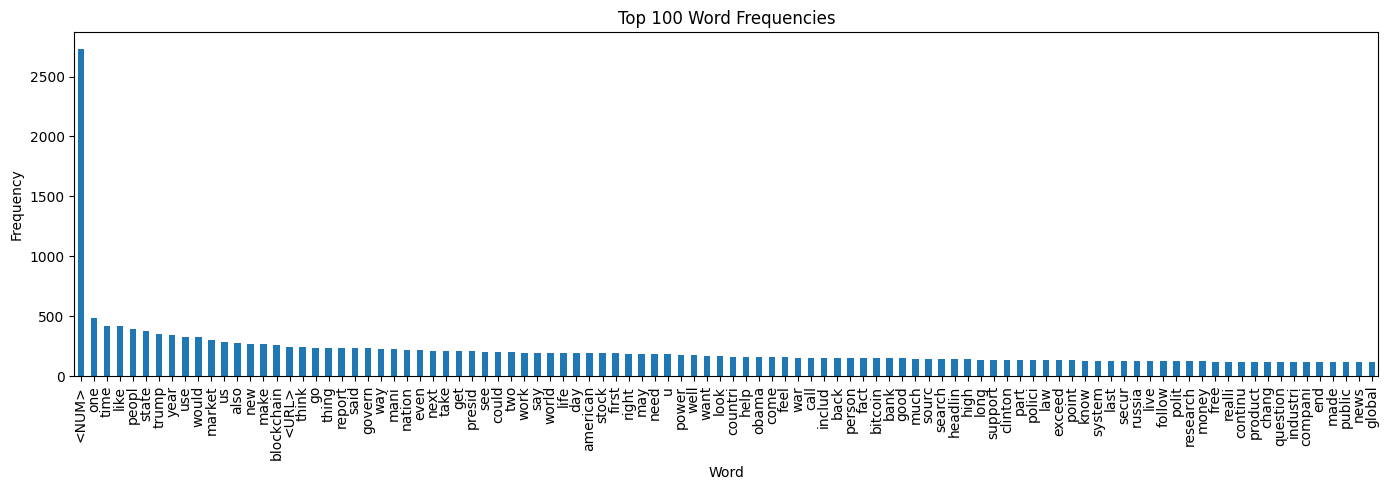

tokenized
<NUM>     2732
one        483
time       418
like       414
peopl      391
          ... 
end        117
made       116
public     116
news       115
global     115
Name: count, Length: 100, dtype: int64

In [14]:
# Asger
def wordcount(df:pd.DataFrame):
    col = df
    if isinstance(col.iloc[0], str):
        tokens = col.str.split().explode()
    else:
        tokens = col.explode()
    
    tokens = tokens.dropna()
    counts = tokens.value_counts(sort=True)
    return counts

def visualize_top_words(
    df: pd.DataFrame,
    token_col: str,
    top_n: int = 10_000,
    loglog: bool = True
):
    """
    df        : cleaned Pandas DataFrame
    token_col: column containing tokenized text (list of tokens per row)
    top_n    : number of most frequent words to visualize 
    
    If top_n <= 100 there will be put labels on for the x axis.
    """
    label_limit = 100
    # Flatten tokens
    counts = wordcount(df[token_col])
    
    counts = counts.head(top_n)

    # Plot
    plt.figure(figsize=(14, 5))

    if loglog:
        ranks = np.arange(1, len(counts) + 1)
        plt.loglog(ranks, counts.values)
        plt.xlabel("Rank")
        plt.ylabel("Frequency")
        plt.title("Word Frequency (Log-Log Scale)")
    else:
        if top_n <= label_limit:
            counts.plot(kind="bar")
            plt.xlabel("Word")
        else:
            plt.plot(counts.values)
            plt.xlabel("Rank")
        plt.ylabel("Frequency")
        plt.title(f"Top {len(counts)} Word Frequencies")

    plt.tight_layout()
    plt.show()

    return counts

visualize_top_words(df,'tokenized',100,loglog=False)

In [15]:
# Mikkel
def data_split(X, y, train_frac = 0.8, test_frac = 0.1, val_frac = 0.1, stratify=None):
    '''
    Splits the data into a training, testing and validation set. The size fraction of each set
    can be specified.

    Returns a tuple containing features (X) and targets (y) for all sets.
    '''

    # Split the dataset into training and other (test + val) set.
    X_train, X_other, y_train, y_other = train_test_split(X, y, test_size=(1-train_frac), stratify=stratify)

    # Split other into test and val set.
    X_test, X_val, y_test, y_val = train_test_split(X_other, y_other, test_size=(val_frac/(test_frac+val_frac)), stratify=stratify)

    return (X_train, X_test, X_val, y_train, y_test, y_val)

In [16]:
def prepare_dataset(data, complex_model = False):
    
    vocab = wordcount(data['tokenized'])[0:10000].index
    if complex_model:
        vectorizer = TfidfVectorizer(vocabulary=vocab, tokenizer=lambda x: x, lowercase=False)
    else:
        vectorizer = CountVectorizer(vocabulary=vocab, tokenizer=lambda x: x, lowercase=False)
    counts = vectorizer.fit_transform(data['tokenized'])

    return counts



In [ ]:
prepare_dataset(df,False)

C:\Users\miche\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 53955 stored elements and shape (250, 9843)>

In [ ]:
#Michelle

from sklearn.ensemble import RandomForestClassifier as RanFor

features = prepare_dataset(df,True)
labels = list(df['type'])

X_train, X_test, X_val, y_train, y_test, y_val = data_split(features,labels)

#model validation to choose optimal hyperparameters

best_val_score = 0
best_parameters = {}

for n_estimators in [10,20,30,40,50,60,70,80,90,100]:
    for max_depth in [None,10,12,14,16,18,20]:
        for max_features in ['sqrt','log2']:
            model = RanFor(
                n_estimators=n_estimators,
                max_depth=max_depth,
                max_features=max_features,
                )
            model.fit(X_train, y_train)
            val_score = model.score(X_val, y_val)
            train_score = model.score(X_train,y_train)

            if val_score > best_val_score:
                best_val_score = val_score
                best_parameters = {
                    'n_estimators': n_estimators,
                    'max_depth': max_depth,
                    'max_features': max_features
                }

print("Best parameters:", best_parameters, "Training accuracy:", train_score, "Validation accuracy:", val_score)


#when figuring out how to do this on big sample without taking an hour, execute the lines below:
#FakeNewsForest = RanFor(n_estimators=best_parameters)
#FakeNewsForest.fit(X_train,y_train)
#FakeNewsForest.predict(X_val)


C:\Users\miche\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
#unique,counts = np.unique_counts(list(df['type']))

#print(unique)


['bias' 'clickbait' 'conspiracy' 'fake' 'hate' 'junksci' 'nan' 'political'
 'reliable' 'unknown' 'unreliable']


## Evaluation

In [ ]:
from sklearn.metrics import f1_score

#evaluation of Logistic regression model

#evaluation of Random forest model

#evaluation of advanced model nr 2